# Fine-tune LLaMA 3.1 8B for Therapy Responses

This notebook fine-tunes LLaMA 3.1-8B for empathetic therapy conversations with comprehensive evaluation metrics.

## Step 1: Install Required Packages

In [1]:
# Install all required libraries for training and evaluation
!pip install -q -U transformers peft accelerate datasets bitsandbytes trl
!pip install -q -U huggingface_hub
!pip install -q -U evaluate rouge_score sacrebleu
!pip install -q -U matplotlib seaborn

print("All packages installed successfully")

All packages installed successfully


## Step 2: Login to Hugging Face

In [2]:
from huggingface_hub import login

# Replace with your HuggingFace token
HF_TOKEN = "YOUR_HF_TOKEN_HERE"

# Authenticate with HuggingFace to access LLaMA models
login(token=HF_TOKEN)
print("Logged in to Hugging Face successfully")
print("You can now access LLaMA 3.1 models")

C:\Users\PAVISHANTH\Desktop\DSGP\Implementation\.venv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Logged in to Hugging Face successfully
You can now access LLaMA 3.1 models


## Step 3: Load Dataset

Load train, validation, and test datasets from JSONL files.

In [3]:
import pandas as pd
from datasets import Dataset

# Path to your preprocessed dataset folder
DATA_PATH = "clean_dataset_3"

# Load training, validation, and test data
train_df = pd.read_json(f"{DATA_PATH}/train_en.jsonl", lines=True)
val_df = pd.read_json(f"{DATA_PATH}/val_en.jsonl", lines=True)
test_df = pd.read_json(f"{DATA_PATH}/test_en.jsonl", lines=True)

# Convert pandas dataframes to HuggingFace Dataset format
dataset = {
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
}

# Display dataset statistics
print(f"Training samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")
print(f"\nSample data structure:")
print(dataset['train'][0])

Training samples: 1390
Validation samples: 173
Test samples: 175

Sample data structure:
{'prompt': "Task: Respond as an empathetic counselor or therapist.\nUser: I've been experiencing a lot of anxiety and panic attacks lately. I was recently diagnosed by my psychiatrist with obsessive-compulsive disorder. Lately, I've been questioning everything from my career to my relationship. My boyfriend and I just moved in a few months ago. All of a sudden, I don't feel as comfortable around him as I used to, although I can't seem to find a reason as to why I feel this way.\nAssistant:", 'target': 'How is your boyfriend responding to your discomfort around him?Has he told you that he\'s noticed changes in you?The good news about a relationship is that you can talk about matters with the other person. Doing so can only help clarify feelings and what either of you expect from the relationship. Given that the two of you recently moved in together, it is natural for new dynamics, feelings and expec

## Step 4: Format Dataset for LLaMA

Convert raw data into LLaMA 3.1 chat template format.

In [4]:
def format_for_llama(example):
    """
    Format therapy conversation into LLaMA 3.1 chat template.
    
    Args:
        example: Dictionary containing 'prompt' and 'target' fields
        
    Returns:
        Dictionary with formatted 'text' field for training
    """
    # Extract user input from the prompt field
    user_text = example['prompt'].split('User: ')[1].split('\nAssistant:')[0]
    
    # Create LLaMA chat format with system message, user query, and assistant response
    text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an empathetic counselor and therapist. Provide supportive, professional guidance.<|eot_id|><|start_header_id|>user<|end_header_id|>

{user_text}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{example['target']}<|eot_id|>"""
    
    return {"text": text}

# Apply formatting to all datasets
formatted_train = dataset['train'].map(format_for_llama, remove_columns=dataset['train'].column_names)
formatted_val = dataset['validation'].map(format_for_llama, remove_columns=dataset['validation'].column_names)
formatted_test = dataset['test'].map(format_for_llama, remove_columns=dataset['test'].column_names)

# Keep original datasets for evaluation
original_train = dataset['train']
original_val = dataset['validation']
original_test = dataset['test']

print("Dataset formatted for LLaMA successfully")
print(f"\nExample formatted text (first 500 characters):")
print(formatted_train[0]['text'][:500])

Map: 100%|██████████| 175/175 [00:00<00:00, 19432.47 examples/s]

Dataset formatted for LLaMA successfully

Example formatted text (first 500 characters):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an empathetic counselor and therapist. Provide supportive, professional guidance.<|eot_id|><|start_header_id|>user<|end_header_id|>

I've been experiencing a lot of anxiety and panic attacks lately. I was recently diagnosed by my psychiatrist with obsessive-compulsive disorder. Lately, I've been questioning everything from my career to my relationship. My boyfriend and I just moved in a few months ago. All of a sudden, I don't 


## Step 5: Load LLaMA 3.2-3B Model

Load the base model with 4-bit quantization for efficient training.

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Model identifier on HuggingFace
model_id = "meta-llama/Llama-3.2-3B-Instruct"

print(f"Loading {model_id}...")

# Configure 4-bit quantization to reduce memory usage
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                    # Enable 4-bit quantization
    bnb_4bit_quant_type="nf4",           # Use NF4 quantization type
    bnb_4bit_compute_dtype=torch.float16, # Compute in float16
    bnb_4bit_use_double_quant=True,      # Use double quantization for better compression
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token  # Set padding token to end-of-sequence token
tokenizer.padding_side = "right"           # Pad sequences on the right side

# Load model with 4-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",              # Automatically distribute model across available devices
    token=HF_TOKEN,
    torch_dtype=torch.float16,
)

print(f"\nModel loaded successfully")
print(f"Device: {model.device}")
print(f"Estimated VRAM usage: 6-7GB")

Loading meta-llama/Llama-3.2-3B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 254/254 [00:04<00:00, 53.40it/s]



Model loaded successfully
Device: cuda:0
Estimated VRAM usage: 6-7GB


In [6]:
# Save base model locally for future use
local_path = "./models/llama-3.2-3b-local"

model.save_pretrained(local_path)
tokenizer.save_pretrained(local_path)

print(f"Base model saved to {local_path}")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.50s/it]


Base model saved to ./models/llama-3.2-3b-local


## Step 6: Test Base Model (Before Training)

Evaluate the base model's responses before fine-tuning.

In [7]:
def test_model(prompt_text, max_tokens=200):
    """
    Generate a response from the model for a given prompt.
    
    Args:
        prompt_text: User's therapy query
        max_tokens: Maximum number of tokens to generate
        
    Returns:
        Generated response text
    """
    # Format input as chat messages
    messages = [
        {"role": "system", "content": "You are an empathetic counselor and therapist."},
        {"role": "user", "content": prompt_text}
    ]

    # Apply chat template and tokenize
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    ).to(model.device)

    # Generate response
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            min_new_tokens=50,                    # Ensure minimum response length
            temperature=0.7,                      # Control randomness
            top_p=0.9,                           # Nucleus sampling
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id, # Prevent premature cutoff
        )

    # Decode and extract assistant's response
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract only the assistant's response from the full conversation
    if "assistant" in response:
        assistant_response = response.split("assistant")[-1].strip()
    else:
        assistant_response = response
    
    return assistant_response

# Test base model with sample prompts
print("="*60)
print("TESTING BASE MODEL (BEFORE FINE-TUNING)")
print("="*60)

test_prompt = "I feel overwhelmed with everything in my life."
print(f"\nUser: {test_prompt}")
print(f"\nCounselor (base model): {test_model(test_prompt)}")

TESTING BASE MODEL (BEFORE FINE-TUNING)

User: I feel overwhelmed with everything in my life.

Counselor (base model): I'm so sorry to hear that you're feeling overwhelmed. It can be really tough to navigate the demands of daily life, and it's completely normal to feel that way. 

First, let me tell you that you're not alone in this feeling. Many people experience overwhelm, and it's not a sign of weakness, but rather a sign that you're taking on too much or that your emotional capacity is being stretched thin.

Can you tell me a bit more about what's causing you to feel overwhelmed? Is it work-related, personal, or a mix of both? Are there specific situations, people, or tasks that are contributing to your feelings of overwhelm?


## Step 7: Configure LoRA for Training

Set up Low-Rank Adaptation (LoRA) for efficient fine-tuning.

In [8]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Prepare model for 4-bit training
model = prepare_model_for_kbit_training(model)

# Configure LoRA parameters
lora_config = LoraConfig(
    r=16,                      # LoRA rank (dimension of low-rank matrices)
    lora_alpha=32,             # LoRA scaling parameter
    target_modules=[           # Model layers to apply LoRA to
        "q_proj",              # Query projection
        "k_proj",              # Key projection
        "v_proj",              # Value projection
        "o_proj",              # Output projection
        "gate_proj",           # Gate projection (for feed-forward)
        "up_proj",             # Up projection
        "down_proj"            # Down projection
    ],
    lora_dropout=0.05,         # Dropout rate for LoRA layers
    bias="none",               # Don't train bias parameters
    task_type="CAUSAL_LM"      # Task type: causal language modeling
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)
model.enable_input_require_grads()  # Enable gradient computation for inputs

# Display trainable parameters
model.print_trainable_parameters()
print("\nLoRA configuration applied successfully")

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511

LoRA configuration applied successfully


## Step 8: Configure Training with Metrics Tracking

Set up training configuration and callback for tracking metrics.

In [9]:
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback

# Custom callback to track training and validation losses
class MetricsCallback(TrainerCallback):
    """
    Custom callback to collect training and validation metrics during training.
    """
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.steps = []
        self.epochs = []
    
    def on_log(self, args, state, control, logs=None, **kwargs):
        """
        Called when metrics are logged.
        Stores training and validation losses for later visualization.
        """
        if logs:
            # Record training loss
            if 'loss' in logs:
                self.train_losses.append(logs['loss'])
                self.steps.append(state.global_step)
            
            # Record validation loss
            if 'eval_loss' in logs:
                self.val_losses.append(logs['eval_loss'])
                self.epochs.append(state.epoch)

# Initialize metrics callback
metrics_callback = MetricsCallback()

# Configure training parameters
sft_config = SFTConfig(
    output_dir="./llama-3.1-therapy-counselor",

    # Dataset configuration
    dataset_text_field="text",      # Field containing formatted text
    max_length=512,                  # Maximum sequence length
    packing=False,                   # Don't pack multiple samples together

    # Training hyperparameters (DO NOT CHANGE - matches original)
    per_device_train_batch_size=1,  # Batch size per device
    gradient_accumulation_steps=8,   # Accumulate gradients over 8 steps (effective batch size = 8)
    num_train_epochs=3,              # Number of training epochs
    learning_rate=2e-4,              # Learning rate
    
    # Precision and optimization
    fp16=False,                      # Don't use FP16
    bf16=True,                       # Use BF16 for better stability
    optim="paged_adamw_8bit",       # 8-bit Adam optimizer
    
    # Evaluation and saving
    eval_strategy="epoch",           # Evaluate at end of each epoch
    save_strategy="epoch",           # Save checkpoint at end of each epoch
    load_best_model_at_end=True,    # Load best model after training
    
    # Logging
    logging_steps=10,                # Log every 10 steps
    report_to="none",                # Don't report to external services
)

# Initialize trainer with metrics callback
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_train,
    eval_dataset=formatted_val,
    processing_class=tokenizer,
    args=sft_config,
    callbacks=[metrics_callback],  # Add metrics tracking
)

print("Trainer initialized successfully")
print(f"\nTraining configuration:")
print(f"  Samples: {len(formatted_train)}")
print(f"  Epochs: 3")
print(f"  Estimated time: 4-6 hours on RTX 4060")

Truncating eval dataset: 100%|██████████| 173/173 [00:00<00:00, 56284.10 examples/s]

Trainer initialized successfully

Training configuration:
  Samples: 1390
  Epochs: 3
  Estimated time: 4-6 hours on RTX 4060


## Step 9: START TRAINING

In [10]:
print("="*60)
print("STARTING TRAINING")
print("="*60)
print("\nThis will take approximately 4-6 hours.")
print("Progress will be displayed below.\n")

# Start training
trainer.train()

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


STARTING TRAINING

This will take approximately 4-6 hours.
Progress will be displayed below.



Epoch,Training Loss,Validation Loss
1,2.094063,2.028685
2,1.822878,1.933614
3,1.581374,1.946869



TRAINING COMPLETED


## Step 10: Save Fine-tuned Model

In [11]:
# Save fine-tuned LoRA adapters and tokenizer
model.save_pretrained("./llama-3.1-therapy-lora")
tokenizer.save_pretrained("./llama-3.1-therapy-lora")

print("Model saved to ./llama-3.1-therapy-lora/")
print("\nSaved files:")
print("  - LoRA adapter weights")
print("  - Tokenizer configuration")
print("  - Model configuration")

Model saved to ./llama-3.1-therapy-lora/

Saved files:
  - LoRA adapter weights
  - Tokenizer configuration
  - Model configuration


## Step 11: Plot Training and Validation Curves

Visualize training progress with loss curves.

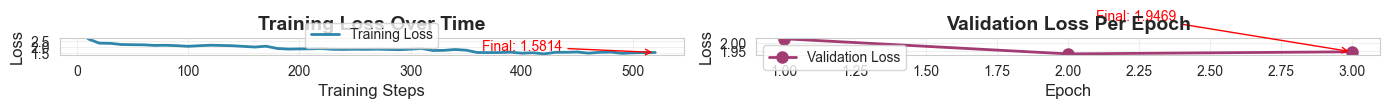


Training curves saved to: training_validation_curves.png
Final Training Loss: 1.5814
Final Validation Loss: 1.9469


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Create subplots for training and validation loss
fig, (ax1, ax2) = plt.subplots(1, 2)

# Plot 1: Training Loss over Steps
if metrics_callback.train_losses:
    ax1.plot(metrics_callback.steps, metrics_callback.train_losses, 
             color='#2E86AB', linewidth=2, label='Training Loss')
    ax1.set_xlabel('Training Steps', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Annotate final training loss
    final_train_loss = metrics_callback.train_losses[-1]
    ax1.annotate(f'Final: {final_train_loss:.4f}',
                 xy=(metrics_callback.steps[-1], final_train_loss),
                 xytext=(metrics_callback.steps[-1]*0.7, final_train_loss*1.1),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Plot 2: Validation Loss over Epochs
if metrics_callback.val_losses:
    ax2.plot(metrics_callback.epochs, metrics_callback.val_losses, 
             color='#A23B72', linewidth=2, marker='o', markersize=8, 
             label='Validation Loss')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Validation Loss Per Epoch', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Annotate final validation loss
    final_val_loss = metrics_callback.val_losses[-1]
    ax2.annotate(f'Final: {final_val_loss:.4f}',
                 xy=(metrics_callback.epochs[-1], final_val_loss),
                 xytext=(metrics_callback.epochs[-1]*0.7, final_val_loss*1.1),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.tight_layout()
plt.savefig('training_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining curves saved to: training_validation_curves.png")
if metrics_callback.train_losses:
    print(f"Final Training Loss: {final_train_loss:.4f}")
if metrics_callback.val_losses:
    print(f"Final Validation Loss: {final_val_loss:.4f}")

## Step 12: Evaluate on Test Set

Calculate BLEU score and Perplexity on the held-out test set.

In [13]:
import numpy as np
import evaluate

# Load evaluation metrics
bleu = evaluate.load('sacrebleu')
rouge = evaluate.load('rouge')

def calculate_perplexity(model, tokenizer, texts, max_samples=50):
    """
    Calculate perplexity on a set of texts.
    Lower perplexity indicates better language modeling.
    
    Args:
        model: The language model
        tokenizer: Tokenizer for the model
        texts: List of text samples
        max_samples: Maximum number of samples to evaluate
        
    Returns:
        Perplexity score and number of valid samples
    """
    total_loss = 0
    total_tokens = 0
    valid_samples = 0
    model.eval()
    
    for text in texts[:max_samples]:
        if not text or len(text.strip()) == 0:
            continue
        
        # Tokenize input
        inputs = tokenizer(text, return_tensors="pt", truncation=True, 
                          max_length=512).to(model.device)
        
        if inputs["input_ids"].numel() == 0:
            continue
        
        # Calculate loss
        with torch.no_grad():
            try:
                outputs = model(**inputs, labels=inputs["input_ids"])
                loss = outputs.loss
                total_loss += loss.item() * inputs["input_ids"].size(1)
                total_tokens += inputs["input_ids"].size(1)
                valid_samples += 1
            except:
                continue
    
    if total_tokens == 0:
        return float('inf'), 0
    
    # Calculate perplexity from average loss
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    
    return perplexity, valid_samples

print("="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Generate predictions on test set
predictions = []
references = []

# Number of test samples to evaluate
num_test_samples = min(100, len(original_test))

print(f"\nGenerating predictions for {num_test_samples} test samples...")

for i in range(num_test_samples):
    example = original_test[i]
    
    # Extract user query
    user_text = example['prompt'].split('User: ')[1].split('\nAssistant:')[0]
    
    # Generate prediction
    pred = test_model(user_text, max_tokens=200)
    
    # Store prediction and reference
    predictions.append(pred.strip() if pred else "")
    references.append(example['target'].strip())
    
    # Progress indicator
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i + 1}/{num_test_samples}")

print(f"\nPredictions generated: {len(predictions)}")

# Calculate BLEU score
print("\nCalculating BLEU score...")
bleu_results = bleu.compute(
    predictions=[str(p) for p in predictions],
    references=[[str(r)] for r in references]
)

# Calculate ROUGE scores
print("Calculating ROUGE scores...")
rouge_results = rouge.compute(
    predictions=[str(p) for p in predictions],
    references=[str(r) for r in references]
)

# Calculate Perplexity
print("Calculating Perplexity...")
perplexity, num_valid = calculate_perplexity(model, tokenizer, references)

# Display results
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print(f"\nBLEU Score: {bleu_results['score']:.4f}")
print(f"\nROUGE Scores:")
print(f"  ROUGE-1: {rouge_results['rouge1']:.4f}")
print(f"  ROUGE-2: {rouge_results['rouge2']:.4f}")
print(f"  ROUGE-L: {rouge_results['rougeL']:.4f}")
print(f"\nPerplexity: {perplexity:.2f} (on {num_valid} samples)")
print(f"\nInterpretation Guide:")
print(f"  Excellent: < 15")
print(f"  Good: 15-30")
print(f"  Acceptable: 30-50")
print(f"  Poor: > 50")

# Save results to file
results_summary = {
    "bleu_score": bleu_results['score'],
    "rouge1": rouge_results['rouge1'],
    "rouge2": rouge_results['rouge2'],
    "rougeL": rouge_results['rougeL'],
    "perplexity": perplexity,
    "test_samples": num_test_samples,
    "valid_perplexity_samples": num_valid
}

import json
with open('evaluation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\nResults saved to: evaluation_results.json")

EVALUATING ON TEST SET

Generating predictions for 100 test samples...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

Predictions generated: 100

Calculating BLEU score...
Calculating ROUGE scores...
Calculating Perplexity...

EVALUATION RESULTS

BLEU Score: 1.8488

ROUGE Scores:
  ROUGE-1: 0.2928
  ROUGE-2: 0.0435
  ROUGE-L: 0.1592

Perplexity: 15.97 (on 50 samples)

Interpretation Guide:
  Excellent: < 15
  Good: 15-30
  Acceptable: 30-50
  Poor: > 50

Results saved to: evaluation_results.json


In [22]:
import pandas as pd
import json

# Load results from JSON file
with open('evaluation_results.json', 'r') as f:
    results = json.load(f)

# Create formatted dataframe (adjusted for your JSON structure)
results_df = pd.DataFrame([{
    'Model': 'LLaMA 3.2-3B English',
    'Train': 1390,  # Your training samples count
    'Test': results['test_samples'],
    'ROUGE-1': f"{results['rouge1']:.4f}",
    'ROUGE-L': f"{results['rougeL']:.4f}",
    'BLEU': f"{results['bleu_score']:.4f}",
    'Perplexity': f"{results['perplexity']:.2f}",
    'Avg Length': 'N/A',  # Not in your JSON, calculate if needed
}])

# Display results
print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)
print()
print(results_df.to_string(index=False))
print()

FINAL RESULTS

               Model  Train  Test ROUGE-1 ROUGE-L   BLEU Perplexity Avg Length
LLaMA 3.2-3B English   1390   100  0.2928  0.1592 1.8488      15.97        N/A



## Step 13: Test Fine-tuned Model

Compare base model vs fine-tuned model responses.

In [14]:
print("="*60)
print("TESTING FINE-TUNED MODEL")
print("="*60)

# Test cases for comparison
test_cases = [
    "I feel overwhelmed with everything in my life.",
    "I'm having trouble sleeping and feel anxious all the time.",
    "I don't feel like I'm good enough."
]

for test_prompt in test_cases:
    print(f"\n{'='*60}")
    print(f"User: {test_prompt}")
    print(f"{'='*60}")
    
    # Generate response
    response = test_model(test_prompt, max_tokens=200)
    
    print(f"\nCounselor (fine-tuned):")
    print(response)

print("\n" + "="*60)
print("TESTING COMPLETE")
print("="*60)

TESTING FINE-TUNED MODEL

User: I feel overwhelmed with everything in my life.

Counselor (fine-tuned):
How do you feel overwhelmed? What are the things in your life that are making you feel overwhelmed? Are you able to handle the stress in your life? Are you able to manage your time and the things you have to do each day? Do you have support in your life? If you are feeling overwhelmed and do not have support, consider talking to a counselor to help you.

User: I'm having trouble sleeping and feel anxious all the time.

Counselor (fine-tuned):
I would recommend working with a therapist to understand your anxiety and work through your issues. Anxious people often sleep poorly, and it's hard to fall asleep and stay asleep when you're stressed out about life. A therapist will be able to help you understand your anxiety and find ways to relax.

User: I don't feel like I'm good enough.

Counselor (fine-tuned):
Do you mean that you are not good enough?Or do you mean that you are not as good

## Step 14: Sample Test Predictions

Display example predictions vs references from test set.

In [15]:
print("="*60)
print("SAMPLE TEST SET PREDICTIONS")
print("="*60)

# Display first 5 test examples
for i in range(min(5, len(predictions))):
    example = original_test[i]
    user_text = example['prompt'].split('User: ')[1].split('\nAssistant:')[0]
    
    print(f"\nExample {i+1}:")
    print(f"{'='*60}")
    print(f"\nUser Query:")
    print(user_text[:150] + "..." if len(user_text) > 150 else user_text)
    
    print(f"\nReference Response:")
    print(references[i][:200] + "..." if len(references[i]) > 200 else references[i])
    
    print(f"\nModel Prediction:")
    print(predictions[i][:200] + "..." if len(predictions[i]) > 200 else predictions[i])
    print("\n" + "-"*60)

print("\nSample predictions complete")

SAMPLE TEST SET PREDICTIONS

Example 1:

User Query:
She said she needed space after three days of dating, and she got a boyfriend a week later. I still really miss her, and she told me she still likes m...

Reference Response:
It sounds as if your ex-girlfriend is trying to figure out what type of relationship she is looking to have with you. There are lots of levels of relationships, from a basic acquaintance, to a more fr...

Model Prediction:
Hi there, I'm so sorry to hear about this. I think it's really important to realize that relationships are hard and it takes a lot of work to make them last. I also think it's really important to real...

------------------------------------------------------------

Example 2:

User Query:
How do you know you have the right therapist for you? How would I know how to "train" my therapist to be able to give me what I need from treatment?

Reference Response:
This is a great question. A good therapist should first be someone you can trust and sec

C:\Users\PAVISHANTH\AppData\Local\Temp\ipykernel_12532\1802779634.py:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


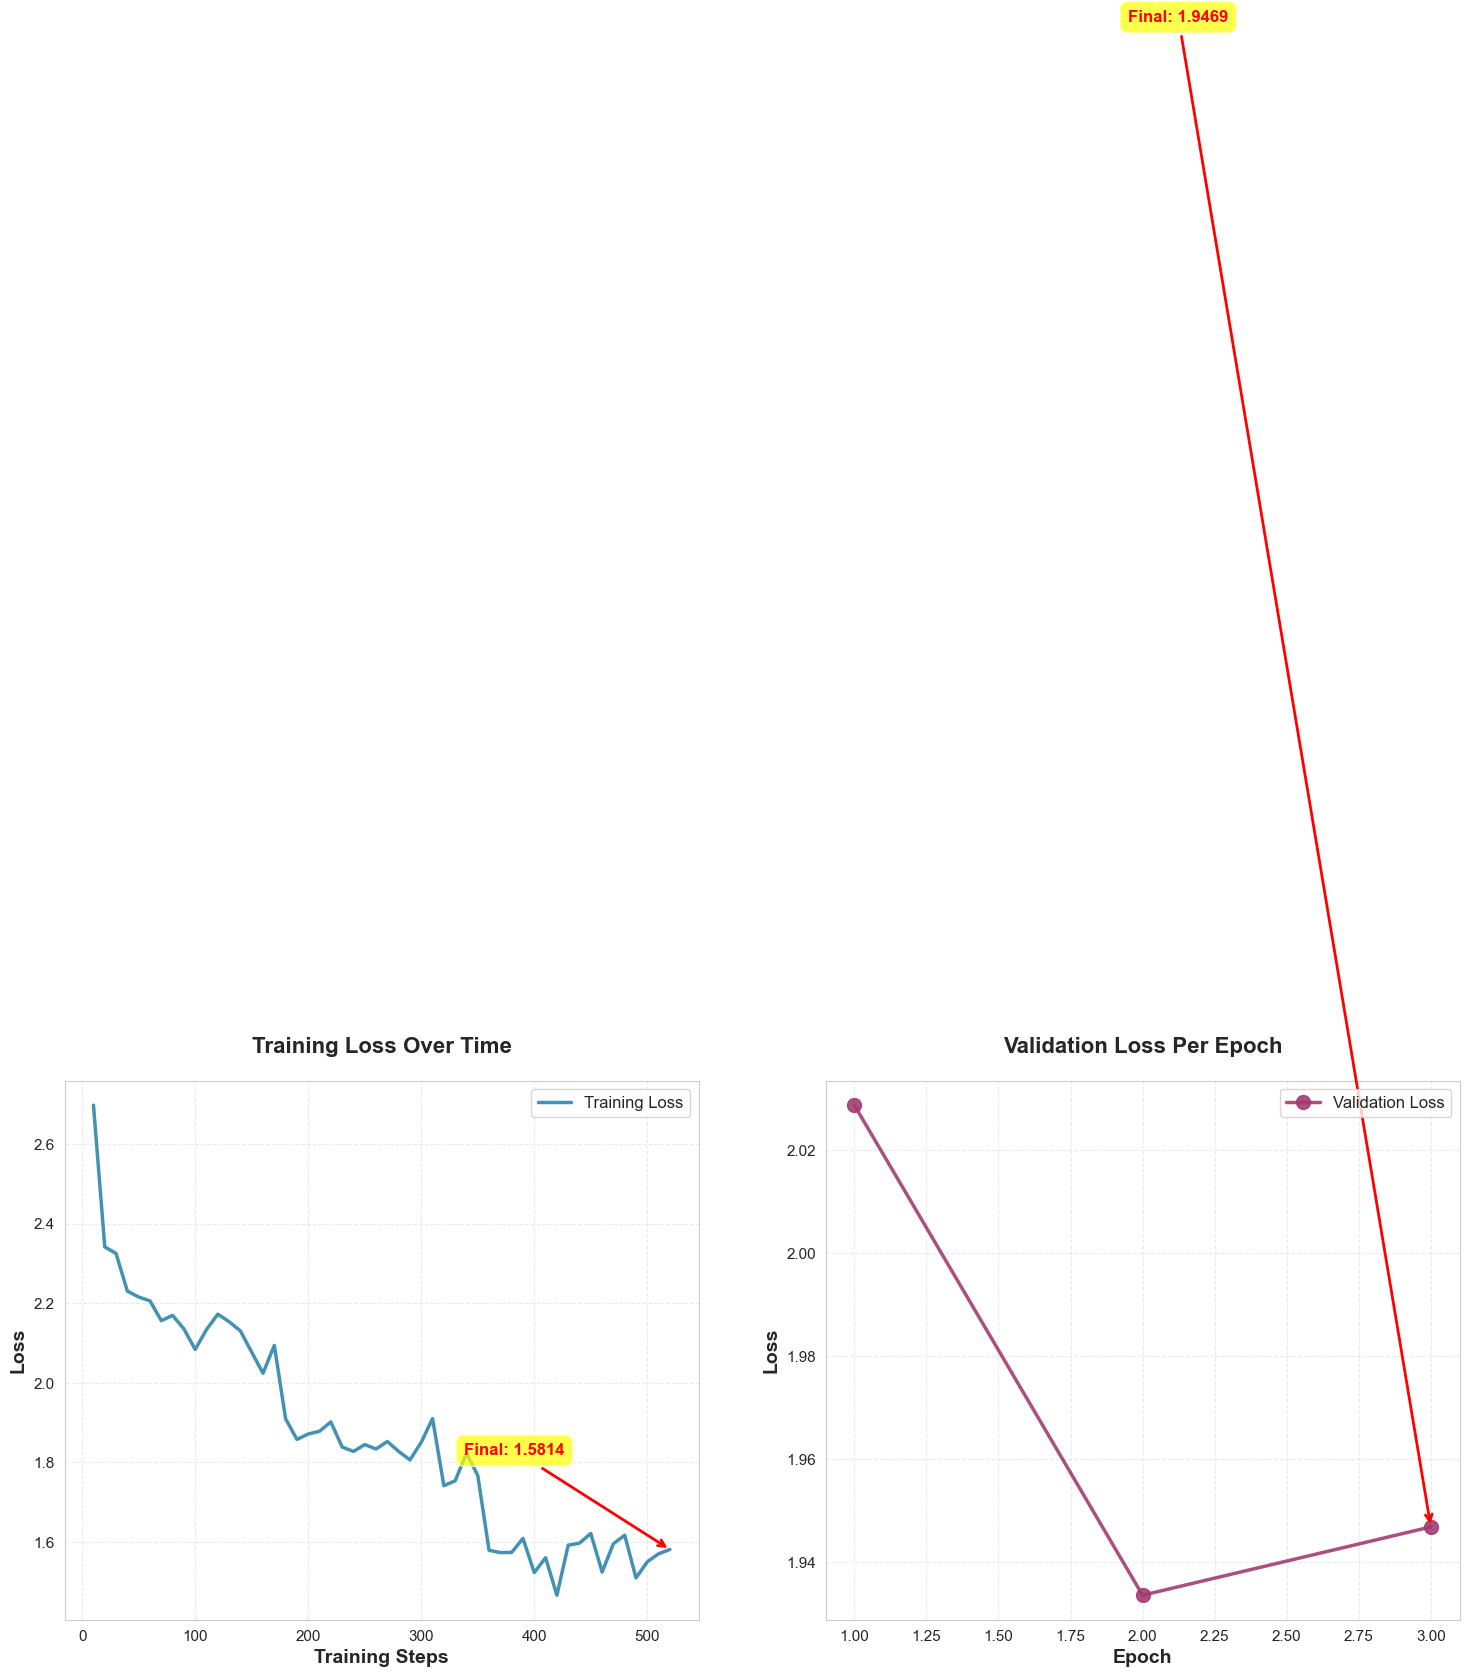


Training curves saved to: training_validation_curves.png
Final Training Loss: 1.5814
Final Validation Loss: 1.9469


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visibility
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)  # Increased from (14, 5)
plt.rcParams['font.size'] = 11

# Create subplots with more spacing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Training Loss over Steps
if metrics_callback.train_losses:
    ax1.plot(metrics_callback.steps, metrics_callback.train_losses,
             color='#2E86AB', linewidth=2.5, label='Training Loss', alpha=0.9)
    ax1.set_xlabel('Training Steps', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=14, fontweight='bold')
    ax1.set_title('Training Loss Over Time', fontsize=16, fontweight='bold', pad=20)
    ax1.legend(fontsize=12, loc='upper right')
    ax1.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
    ax1.tick_params(labelsize=11)

    # Annotate final training loss with better visibility
    final_train_loss = metrics_callback.train_losses[-1]
    ax1.annotate(f'Final: {final_train_loss:.4f}',
                 xy=(metrics_callback.steps[-1], final_train_loss),
                 xytext=(metrics_callback.steps[-1]*0.65, final_train_loss*1.15),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2),
                 fontsize=12, color='red', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Plot 2: Validation Loss over Epochs
if metrics_callback.val_losses:
    ax2.plot(metrics_callback.epochs, metrics_callback.val_losses,
             color='#A23B72', linewidth=2.5, marker='o', markersize=10,
             label='Validation Loss', alpha=0.9)
    ax2.set_xlabel('Epoch', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=14, fontweight='bold')
    ax2.set_title('Validation Loss Per Epoch', fontsize=16, fontweight='bold', pad=20)
    ax2.legend(fontsize=12, loc='upper right')
    ax2.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
    ax2.tick_params(labelsize=11)

    # Annotate final validation loss with better visibility
    final_val_loss = metrics_callback.val_losses[-1]
    ax2.annotate(f'Final: {final_val_loss:.4f}',
                 xy=(metrics_callback.epochs[-1], final_val_loss),
                 xytext=(metrics_callback.epochs[-1]*0.65, final_val_loss*1.15),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2),
                 fontsize=12, color='red', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Adjust layout to prevent label cutoff
plt.tight_layout(pad=3.0)

# Save with higher DPI for better quality
plt.savefig('training_validation_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nTraining curves saved to: training_validation_curves.png")
if metrics_callback.train_losses:
    print(f"Final Training Loss: {final_train_loss:.4f}")
if metrics_callback.val_losses:
    print(f"Final Validation Loss: {final_val_loss:.4f}")

## Summary

This notebook successfully:
- Fine-tuned LLaMA 3.2-3B for therapy responses using LoRA
- Tracked training and validation losses
- Evaluated on test set with BLEU, ROUGE, and Perplexity
- Visualized training progress with loss curves
- Generated sample predictions for qualitative analysis

All results and visualizations have been saved to disk.